# Ultrasonik Kalınlık Verisi ile Makine Öğrenmesi Model Eğitimi ve DSP Karşılaştırması

Bu çalışmada, **316 Paslanmaz Çelik basamaklı kalibrasyon bloğundan** (5.0, 10.0, 15.0, 20.0 ve 25.0 mm kalınlıklar), **ICHF016 prob** ve **Keysight DSOX3012T osiloskop / JSR DPR300 pulser** donanımıyla toplanmış gerçek ultrasonik dalga formları kullanılarak kalınlık kestirim modelleri eğitilmektedir.

Proje kapsamında:
1. `seshizi_ml/ultrasonic.py` içerisindeki klasik sayısal sinyal işleme (**DSP**) tabanlı ses hızı/kalınlık analizi uygulanacaktır.
2. Ham dalga formlarından **zaman, zarf (Hilbert), otokorelasyon ve frekans (FFT)** alanında kapsamlı öznitelikler çıkarılacaktır (Çok iş parçacıklı / **Multi-threaded** paralel işleme ile).
3. Çeşitli Makine Öğrenmesi (**Random Forest, Gradient Boosting, KNN, MLP**) modelleri eğitilecek ve başarımları test edilecektir.
4. Klasik DSP ile ML modelleri **genel doğruluk** ve **farklı donanım ayar grupları (`settings_variant`)** altında ayrıntılı olarak kıyaslanacaktır.
5. En başarılı model `dataset/models/thickness_model.pkl` olarak kaydedilecek ve endüstriyel kullanım için **Hibrit Karar Mimarisi** sunulacaktır.


## Adım 1: Ortam Kurulumu ve Kütüphanelerin Yüklenmesi

**Neden bunu yapıyoruz?**
Ultrasonik sinyal işleme, çok iş parçacıklı (multithreaded) özellik mühendisliği, makine öğrenmesi model eğitimi, çapraz doğrulama ve yüksek kaliteli grafik görselleştirmeleri gerçekleştirmek için gerekli temel bilimsel kütüphaneleri (`numpy`, `pandas`, `scipy`, `scikit-learn`, `matplotlib`, `joblib`, `concurrent.futures`) ve projenin kendi DSP analiz modülünü (`seshizi_ml.ultrasonic`) yüklüyoruz. Ayrıca görselleştirmelerin okunaklı ve yayın kalitesinde olması için genel grafik stillerini ve tekrarlanabilirlik (reproducibility) tohumunu yapılandırıyoruz.


In [1]:
%matplotlib inline

import os
import sys
import json
import time
import warnings
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import scipy.signal as signal
import scipy.fft
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import joblib

# Sklearn modülleri
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Proje ana dizinini belirle
current_dir = os.path.abspath(os.getcwd())
if os.path.basename(current_dir) == "notebooks":
    project_root = os.path.abspath(os.path.join(current_dir, ".."))
else:
    project_root = current_dir

if project_root not in sys.path:
    sys.path.insert(0, project_root)

import seshizi_ml.ultrasonic as ultrasonic

# Uyarıları ve grafik ayarlarını yapılandır
warnings.filterwarnings('ignore')
np.random.seed(42)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

print(f"Çalışma dizini: {project_root}")
print(f"Kullanılabilir CPU Çekirdek Sayısı: {os.cpu_count()}")
print(f"NumPy: {np.__version__}, Pandas: {pd.__version__}, Scikit-learn sürümü hazır.")
print(f"Klasik DSP Modülü başarıyla yüklendi: {ultrasonic.__file__}")


Çalışma dizini: C:\Cem\Staj\seshizi-ml
Kullanılabilir CPU Çekirdek Sayısı: 16
NumPy: 2.5.1, Pandas: 3.0.5, Scikit-learn sürümü hazır.
Klasik DSP Modülü başarıyla yüklendi: C:\Cem\Staj\seshizi-ml\seshizi_ml\ultrasonic.py


## Adım 2: Veri Seti İndeksinin Yüklenmesi ve Lazy Dalga Formu Okuyucu

**Neden bunu yapıyoruz?**
`dataset/index.jsonl` dosyasında 595 adet ölçüm kaydının (capture) metadata bilgileri (hedef kalınlık `thickness_mm`, donanım ayarları `gain`, `filters`, `damping` vb.) yer alır. Her kaydın dalga formu ise `dataset/raw/<id>.csv` dosyasında iki sütun halinde (`t_s` zaman ve `v_volt` genlik) saklanmaktadır. Dalga formlarının satır sayıları ve zaman tabanları (`time_per_div_s`) osiloskop ayarlarına göre farklılık gösterir (~10.000 - 20.000 satır). Belleği gereksiz şişirmemek ve esnekliği korumak için dalga formlarını ihtiyaç anında okuyacak bir `load_waveform(row)` yardımcı fonksiyonu tanımlıyoruz.


In [2]:
# 1. index.jsonl dosyasını oku
index_file = os.path.join(project_root, "dataset", "index.jsonl")
records = []
with open(index_file, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

df_index = pd.DataFrame(records)
print(f"Toplam capture sayısı: {len(df_index)}")
print(f"Mevcut sütunlar: {list(df_index.columns)}")

# 2. Dalga formu okuyucu fonksiyon (Lazy Loader)
def load_waveform(row, base_dir=project_root):
    """Bir metadata satırından veya dosya yolundan zaman (t_s) ve voltaj (v_volt) dizilerini okur."""
    if isinstance(row, (dict, pd.Series)):
        csv_rel = row["csv_path"]
    else:
        csv_rel = str(row)
    
    full_path = os.path.join(base_dir, "dataset", csv_rel)
    df_raw = pd.read_csv(full_path)
    t = df_raw["t_s"].to_numpy(dtype=np.float64)
    v = df_raw["v_volt"].to_numpy(dtype=np.float64)
    return t, v

# Örnek bir kaydı test et
sample_t, sample_v = load_waveform(df_index.iloc[0])
print(f"Örnek dalga formu: {len(sample_t)} nokta, Zaman aralığı: [{sample_t[0]*1e6:.2f}, {sample_t[-1]*1e6:.2f}] µs, Voltaj aralığı: [{sample_v.min():.2f}, {sample_v.max():.2f}] V")

# DataFrame ilk 5 satır gösterimi
df_index[['id', 'thickness_mm', 'settings_variant', 'gain', 'hp_filter_mhz', 'lp_filter_mhz', 'damping', 'averaging']].head()


Toplam capture sayısı: 595
Mevcut sütunlar: ['material', 'material_label', 'reference_velocity_m_s', 'thickness_mm', 'echoes_requested', 'averaging', 'probe', 'time_per_div_s', 'volts_per_div', 'gain', 'hp_filter_mhz', 'lp_filter_mhz', 'prf', 'pulse_amplitude', 'pulse_energy', 'damping', 'id', 'csv_path', 'timestamp', 'settings_variant']
Örnek dalga formu: 20834 nokta, Zaman aralığı: [-5.00, 45.00] µs, Voltaj aralığı: [-3.30, 3.94] V


,id,thickness_mm,settings_variant,gain,hp_filter_mhz,lp_filter_mhz,damping,averaging
0,20260820_154155_9eb6aab5,25.0,NaN,33,1.0,5.0,1,32
1,20260820_154157_c447a837,25.0,NaN,33,1.0,5.0,1,32
2,20260820_154158_58dcb98a,25.0,NaN,33,1.0,5.0,1,32
3,20260820_154158_1e9e316b,25.0,NaN,33,1.0,5.0,1,32
4,20260820_154159_e2dde829,25.0,NaN,33,1.0,5.0,1,32


## Adım 3: Keşifsel Veri Analizi (EDA)

**Neden bunu yapıyoruz?**
Veri setinin yapısını, sınıf dağılımlarını ve fiziksel sinyal davranışlarını anlamak başarılı bir modelleme için şarttır:
1. Hedef etiket (`thickness_mm`) ve pulser/osiloskop ayar grubu (`settings_variant`) dağılımlarını inceliyoruz.
2. Farklı basamak kalınlıkları (5.0, 10.0, 15.0, 20.0, 25.0 mm) için dalga formlarını çizerek kalınlık arttıkça yankı paketleri arasındaki uçuş süresinin (Time-of-Flight / ToF) nasıl geciktiğini görselleştiriyoruz.
3. Aynı kalınlıkta (25 mm) farklı ayar varyantlarını (temiz, düşük kazanç, yüksek kazanç/doygunluk, kötü kuplaj, hızlı PRF) ve bunların frekans spektrumlarını (FFT) kıyaslayarak donanım varyasyonlarının sinyal morfolojisine etkisini inceliyoruz.


=== Kalınlık Dağılımı ===
              Örnek Sayısı
thickness_mm              
5.0                    119
10.0                   119
15.0                   119
20.0                   119
25.0                   119

=== Ayar Grupları (settings_variant) Dağılımı ===
settings_variant
None (Varsayılan)            100
gurultulu_yuksek_kazanc       25
5mm_optimize                  25
yuksek_damping_kisa_darbe     25
zayif_sinyal_dusuk_kazanc     25
genis_bant_dusuk_hp           25
dusuk_ortalama_averaging1     25
kotu_kuplaj                   25
yanlis_hizalama               25
hizli_prf_cakisma             25
Name: count, dtype: int64


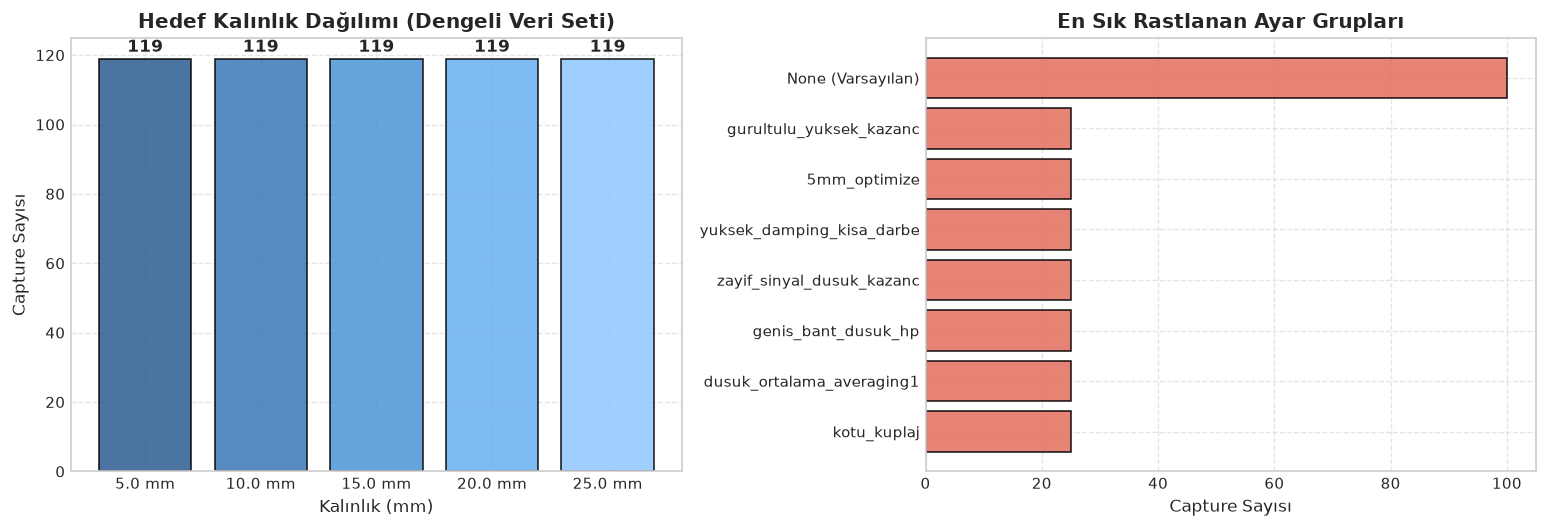

In [3]:
# 1. Dağılım Tabloları
print("=== Kalınlık Dağılımı ===")
display_thickness = df_index['thickness_mm'].value_counts().sort_index().to_frame(name='Örnek Sayısı')
print(display_thickness)

print("\n=== Ayar Grupları (settings_variant) Dağılımı ===")
variant_counts = df_index['settings_variant'].fillna('None (Varsayılan)').value_counts()
print(variant_counts.head(10))

# 2. Grafik 1: Veri Seti Dağılımları
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Kalınlık Dağılımı Bar Grafiği
colors = ['#2b5c8f', '#3878b4', '#4a94d8', '#68aff0', '#8ec7ff']
axes[0].bar([f"{t:.1f} mm" for t in display_thickness.index], display_thickness['Örnek Sayısı'], color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title("Hedef Kalınlık Dağılımı (Dengeli Veri Seti)", fontweight='bold')
axes[0].set_xlabel("Kalınlık (mm)")
axes[0].set_ylabel("Capture Sayısı")
axes[0].grid(True, linestyle='--', alpha=0.5)
for i, v in enumerate(display_thickness['Örnek Sayısı']):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# En Sık Ayar Grupları
top_variants = variant_counts.head(8)
axes[1].barh(top_variants.index[::-1], top_variants.values[::-1], color='#e26d5c', edgecolor='black', alpha=0.85)
axes[1].set_title("En Sık Rastlanan Ayar Grupları", fontweight='bold')
axes[1].set_xlabel("Capture Sayısı")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


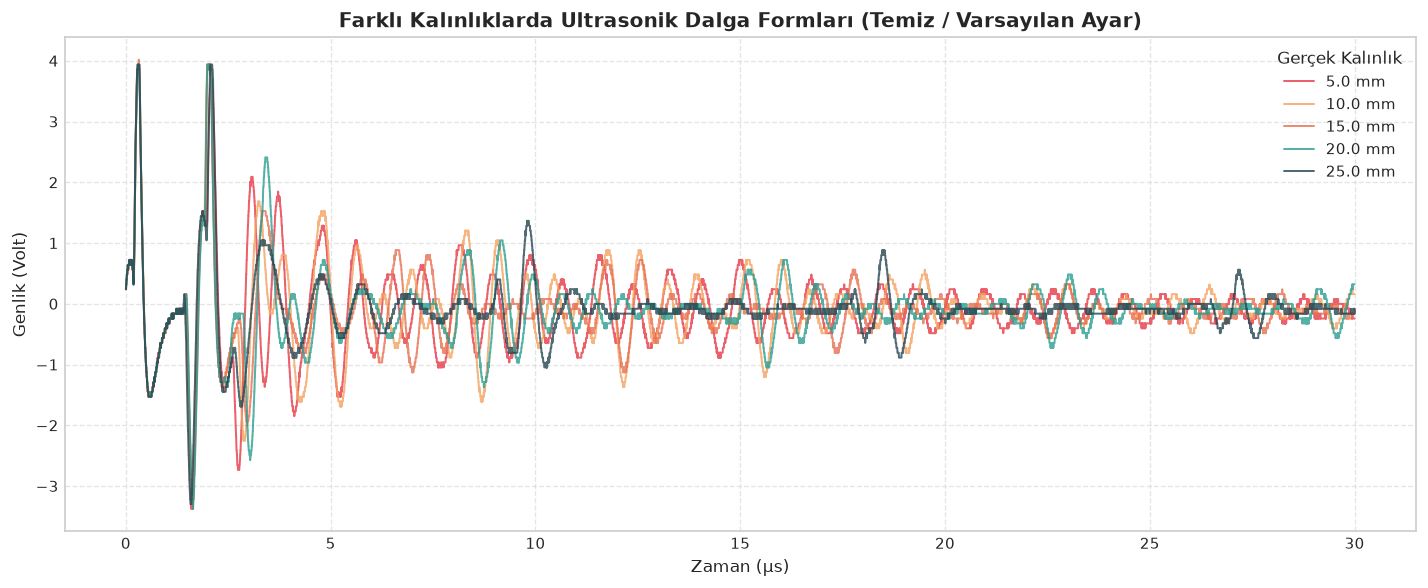

In [4]:
# 3. Grafik 2: Farklı Kalınlıklarda Temiz Dalga Formları (ToF Farkı)
fig, ax = plt.subplots(figsize=(12, 5))

clean_df = df_index[df_index['settings_variant'].isna() | (df_index['settings_variant'] == 'None')]
thicknesses = [5.0, 10.0, 15.0, 20.0, 25.0]
color_palette = ['#e63946', '#f4a261', '#e76f51', '#2a9d8f', '#264653']

for th, col in zip(thicknesses, color_palette):
    subset = clean_df[clean_df['thickness_mm'] == th]
    if len(subset) > 0:
        row = subset.iloc[0]
        t, v = load_waveform(row)
        mask = (t >= 0) & (t <= 30e-6)
        ax.plot(t[mask] * 1e6, v[mask], label=f"{th:.1f} mm", color=col, alpha=0.8, linewidth=1.2)

ax.set_title("Farklı Kalınlıklarda Ultrasonik Dalga Formları (Temiz / Varsayılan Ayar)", fontweight='bold')
ax.set_xlabel("Zaman (µs)")
ax.set_ylabel("Genlik (Volt)")
ax.legend(title="Gerçek Kalınlık", loc="upper right")
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


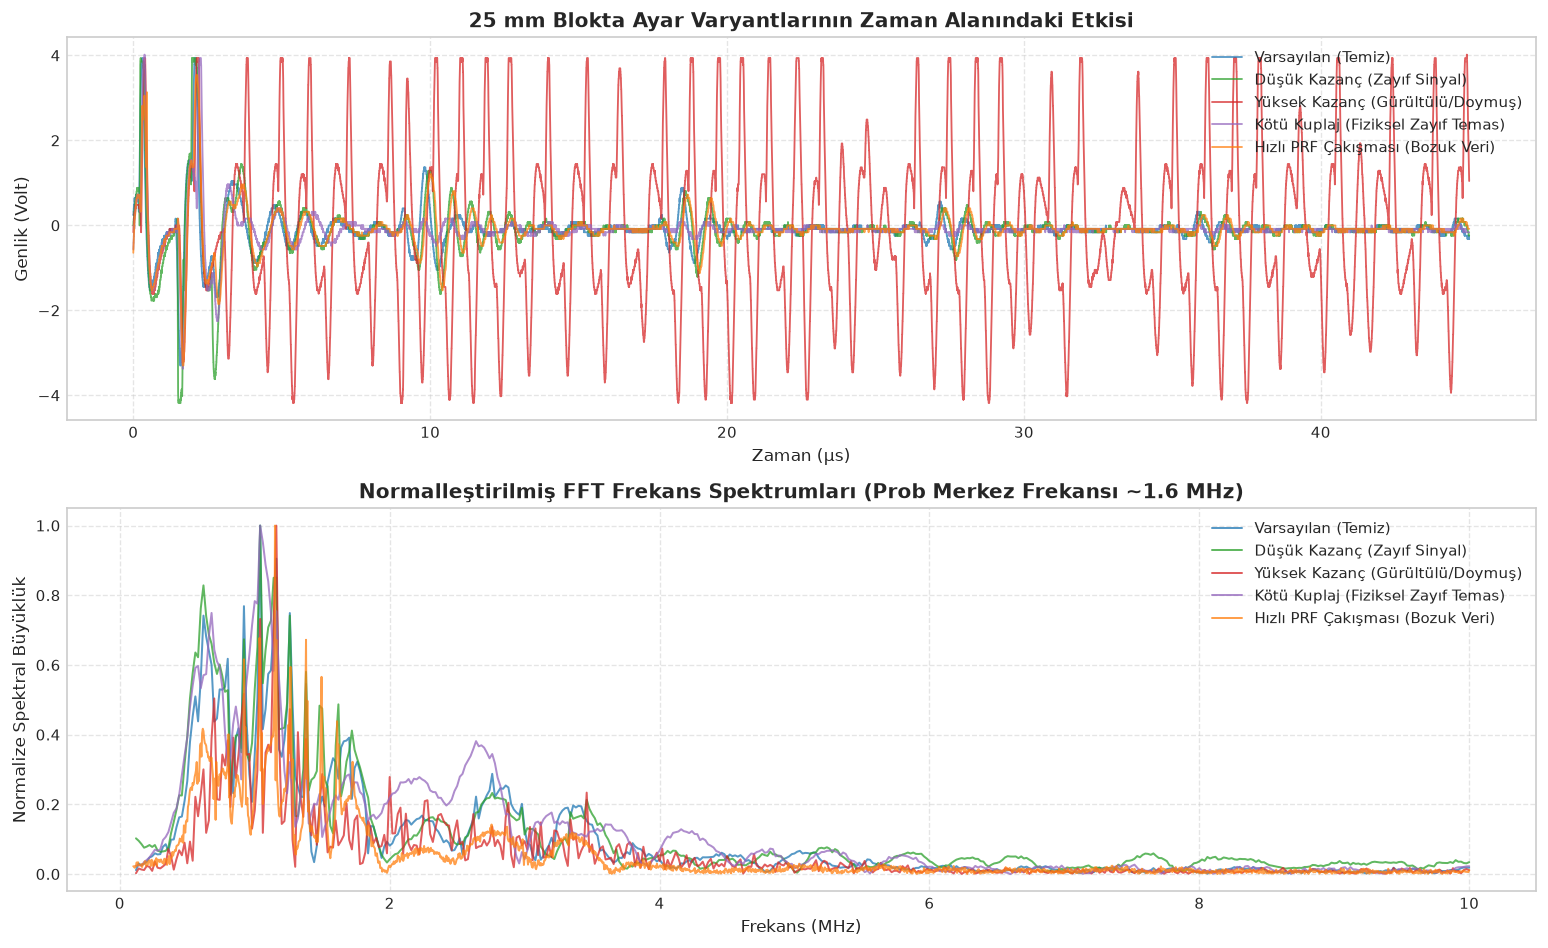

In [5]:
# 4. Grafik 3: 25 mm Kalınlıkta Farklı Ayar Varyantları ve Frekans Spektrumları
variants_to_plot = [
    (None, "Varsayılan (Temiz)", '#1f77b4'),
    ("zayif_sinyal_dusuk_kazanc", "Düşük Kazanç (Zayıf Sinyal)", '#2ca02c'),
    ("gurultulu_yuksek_kazanc", "Yüksek Kazanç (Gürültülü/Doymuş)", '#d62728'),
    ("kotu_kuplaj", "Kötü Kuplaj (Fiziksel Zayıf Temas)", '#9467bd'),
    ("hizli_prf_cakisma", "Hızlı PRF Çakışması (Bozuk Veri)", '#ff7f0e')
]

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

for var_key, var_label, col in variants_to_plot:
    if var_key is None:
        sub = df_index[(df_index['thickness_mm'] == 25.0) & (df_index['settings_variant'].isna() | (df_index['settings_variant'] == 'None'))]
    else:
        sub = df_index[(df_index['thickness_mm'] == 25.0) & (df_index['settings_variant'] == var_key)]
    
    if len(sub) > 0:
        row = sub.iloc[0]
        t, v = load_waveform(row)
        
        # Zaman alanı çizimi (0 - 45 µs)
        mask = (t >= 0) & (t <= 45e-6)
        axes[0].plot(t[mask] * 1e6, v[mask], label=var_label, color=col, alpha=0.75, linewidth=1.1)
        
        # Frekans spektrumu (FFT)
        dt = np.mean(np.diff(t))
        fft_v = np.abs(np.fft.rfft(v))
        freqs = np.fft.rfftfreq(len(v), d=dt) / 1e6 # MHz
        
        f_mask = (freqs >= 0.1) & (freqs <= 10.0)
        axes[1].plot(freqs[f_mask], fft_v[f_mask] / np.max(fft_v[f_mask] + 1e-12), label=var_label, color=col, alpha=0.75, linewidth=1.2)

axes[0].set_title("25 mm Blokta Ayar Varyantlarının Zaman Alanındaki Etkisi", fontweight='bold')
axes[0].set_xlabel("Zaman (µs)")
axes[0].set_ylabel("Genlik (Volt)")
axes[0].legend(loc="upper right", framealpha=0.9)
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].set_title("Normalleştirilmiş FFT Frekans Spektrumları (Prob Merkez Frekansı ~1.6 MHz)", fontweight='bold')
axes[1].set_xlabel("Frekans (MHz)")
axes[1].set_ylabel("Normalize Spektral Büyüklük")
axes[1].legend(loc="upper right", framealpha=0.9)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## Adım 4: Veri Temizleme ve Anomali Ayrımı (Hızlı PRF Çakışması)

**Neden bunu yapıyoruz?**
`hizli_prf_cakisma` varyantında (25 kayıt), darbe tekrarlama frekansı (PRF) çok yüksek seçildiği için bir önceki atımın yankıları henüz sönümlenmeden sisteme yeni bir darbe bindirilmiştir. Bu fiziksel çakışma (pulse collision) regresyon modellerini yanıltacağı ve gerçek dünya şartlarında "geçersiz/hatalı ölçüm" olarak reddedilmesi gerektiği için ana eğitim/test setinden ayrılır (`df_clean` ve `df_invalid`). Bu kayıtlar, sistemin geçersiz ölçümleri ayırt edebilme yeteneğini test etmek için Adım 10'daki mini-deneyde kullanılacaktır.


Ana Regresyon Veri Seti (df_clean): 570 kayıt
Ayrılan Anomali / Geçersiz Veri Seti (df_invalid): 25 kayıt


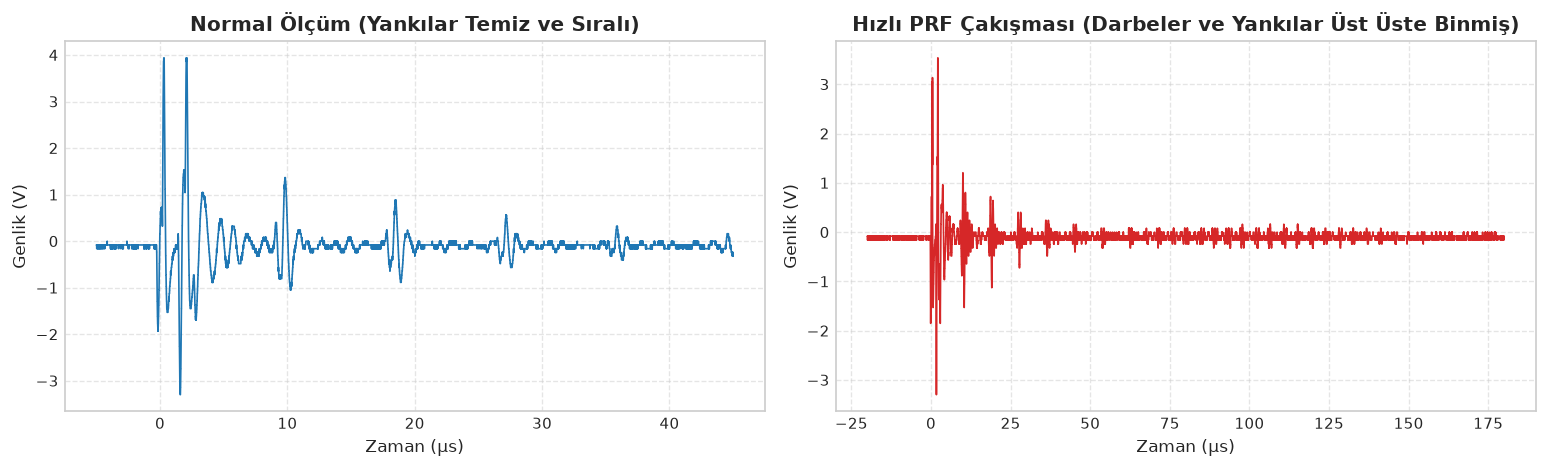

In [6]:
# 1. hizli_prf_cakisma kayıtlarını ana regresyon setinden filtrele
df_invalid = df_index[df_index['settings_variant'] == 'hizli_prf_cakisma'].copy().reset_index(drop=True)
df_clean = df_index[df_index['settings_variant'] != 'hizli_prf_cakisma'].copy().reset_index(drop=True)

print(f"Ana Regresyon Veri Seti (df_clean): {len(df_clean)} kayıt")
print(f"Ayrılan Anomali / Geçersiz Veri Seti (df_invalid): {len(df_invalid)} kayıt")

# 2. Çakışma etkisini zoom-in ile görselleştir
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

row_norm = df_clean[(df_clean['thickness_mm'] == 25.0) & df_clean['settings_variant'].isna()].iloc[0]
t_n, v_n = load_waveform(row_norm)
axes[0].plot(t_n * 1e6, v_n, color='#1f77b4', linewidth=1.0)
axes[0].set_title("Normal Ölçüm (Yankılar Temiz ve Sıralı)", fontweight='bold')
axes[0].set_xlabel("Zaman (µs)")
axes[0].set_ylabel("Genlik (V)")
axes[0].grid(True, linestyle='--', alpha=0.5)

row_bad = df_invalid[df_invalid['thickness_mm'] == 25.0].iloc[0]
t_b, v_b = load_waveform(row_bad)
axes[1].plot(t_b * 1e6, v_b, color='#d62728', linewidth=1.0)
axes[1].set_title("Hızlı PRF Çakışması (Darbeler ve Yankılar Üst Üste Binmiş)", fontweight='bold')
axes[1].set_xlabel("Zaman (µs)")
axes[1].set_ylabel("Genlik (V)")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## Adım 5: Çok İş Parçacıklı (Multi-threaded) Hızlı Özellik Çıkarımı

**Neden bunu yapıyoruz?**
Ultrasonik dalga formlarından kalınlık kestirimi için hem **Klasik DSP** (`seshizi_ml.ultrasonic.analyze`) hem de **istatistiksel, zarf (Hilbert), FFT frekans bantları ve FFT otokorelasyon** özniteliklerini çıkarıyoruz. 

570 adet dosyanın diskten okunması (I/O) ve her bir dalga formu üzerinde sinyal işleme adımlarının gerçekleştirilmesi sıralı (sequential) çalıştırıldığında zaman almaktadır. Süreci hızlandırmak için `concurrent.futures.ThreadPoolExecutor` kullanarak mevcut tüm CPU çekirdekleri üzerinde paralel iş parçacıkları (**Multi-threading**) ile öznitelik çıkarımını saniyeler seviyesine indiriyoruz.


In [7]:
def extract_all_features(row, base_dir=project_root):
    """Tek bir ölçüm kaydından hem DSP hem de istatistiksel/spektral ML özelliklerini çıkarır."""
    t, v = load_waveform(row, base_dir=base_dir)
    n_pts = len(t)
    dt = np.mean(np.diff(t))
    fs = 1.0 / dt
    th_nominal_m = float(row['thickness_mm']) / 1000.0
    ref_velocity = 5740.0 # 316 Paslanmaz Çelik referans ses hızı (m/s)

    # 1. Klasik DSP Analizi (seshizi_ml/ultrasonic.py)
    try:
        expected_round_trip = 2.0 * th_nominal_m / ref_velocity
        span_s = float(t[-1] - t[0]) if n_pts > 1 else 0.0
        trips_available = span_s / expected_round_trip if expected_round_trip > 0 else 4
        dynamic_max_echoes = int(min(40, max(4, trips_available + 1)))
        dsp_res = ultrasonic.analyze(t, v, thickness_m=th_nominal_m, skip_first_packet=True, reference_velocity=ref_velocity, max_echoes=dynamic_max_echoes)
        dsp_found = 1 if dsp_res.get('found', False) else 0
        dsp_coherence = float(dsp_res.get('coherence', 0.0) or 0.0)
        dsp_round_trip_s = float(dsp_res.get('envelope_round_trip_s', 0.0) or 0.0)
        dsp_velocity = float(dsp_res.get('velocity', 0.0) or 0.0)
        dsp_n_packets = len(dsp_res.get('packets', []))
        dsp_warnings_count = len(dsp_res.get('warnings', []))
        dsp_noise_level = float(dsp_res.get('noise_level', 0.0) or 0.0)
    except Exception:
        dsp_found, dsp_coherence, dsp_round_trip_s, dsp_velocity = 0, 0.0, 0.0, 0.0
        dsp_n_packets, dsp_warnings_count, dsp_noise_level = 0, 0, 0.0

    # DSP kalınlık tahmini: d = v_ref * dt / 2 (mm cinsinden)
    dsp_thickness_est_mm = (ref_velocity * dsp_round_trip_s / 2.0) * 1000.0 if dsp_round_trip_s > 0 else 0.0

    # 2. Zaman ve Genlik İstatistikleri
    v_abs = np.abs(v)
    max_abs_v = float(np.max(v_abs))
    min_v = float(np.min(v))
    max_v = float(np.max(v))
    ptp_v = float(max_v - min_v)
    mean_v = float(np.mean(v))
    std_v = float(np.std(v))
    rms_v = float(np.sqrt(np.mean(v**2)))
    skew_v = float(skew(v))
    kurt_v = float(kurtosis(v))
    energy_v = float(np.sum(v**2) * dt)
    zcr = float(np.sum(np.diff(v > 0) != 0) / n_pts)

    # 3. Hızlı Hilbert Zarfı (scipy.fft.next_fast_len)
    fast_len = scipy.fft.next_fast_len(n_pts)
    analytic_signal = signal.hilbert(v, N=fast_len)[:n_pts]
    envelope = np.abs(analytic_signal)
    env_max = float(np.max(envelope))
    env_mean = float(np.mean(envelope))
    env_std = float(np.std(envelope))
    env_auc = float(np.sum(envelope) * dt)

    # Zarf Ağırlık Merkezi (Envelope Centroid)
    t_rel = t - t[0]
    total_env = np.sum(envelope) + 1e-12
    env_centroid_t = float(np.sum(t_rel * envelope) / total_env)

    # Zarf Tepeleri (En az 0.5 µs aralıklı)
    min_peak_dist = max(1, int(0.5e-6 / dt))
    peaks, _ = signal.find_peaks(envelope, distance=min_peak_dist, prominence=0.08 * env_max)
    peak_times = t[peaks] if len(peaks) > 0 else np.array([0.0])
    peak_amps = envelope[peaks] if len(peaks) > 0 else np.array([0.0])

    p1_t = float(peak_times[0]) if len(peak_times) > 0 else 0.0
    p2_t = float(peak_times[1]) if len(peak_times) > 1 else p1_t
    p3_t = float(peak_times[2]) if len(peak_times) > 2 else p2_t

    delta_t_21 = max(0.0, p2_t - p1_t)
    delta_t_32 = max(0.0, p3_t - p2_t)
    p1_amp = float(peak_amps[0]) if len(peak_amps) > 0 else 0.0
    p2_amp = float(peak_amps[1]) if len(peak_amps) > 1 else 0.0
    p3_amp = float(peak_amps[2]) if len(peak_amps) > 2 else p2_amp
    amp_ratio_21 = p2_amp / (p1_amp + 1e-6)
    amp_ratio_32 = p3_amp / (p2_amp + 1e-6)

    # 4. Hızlı FFT Tabanlı Otokorelasyon (Yankı Periyodikliği)
    env_centered = envelope - env_mean
    autocorr = signal.correlate(env_centered, env_centered, mode='full', method='fft')
    autocorr = autocorr[len(autocorr)//2:]
    autocorr_norm = autocorr / (autocorr[0] + 1e-12)

    min_lag_idx = int(0.8e-6 / dt)
    if len(autocorr_norm) > min_lag_idx + 10:
        ac_peaks, _ = signal.find_peaks(autocorr_norm[min_lag_idx:], prominence=0.05)
        if len(ac_peaks) > 0:
            best_ac_idx = min_lag_idx + ac_peaks[0]
            autocorr_tau_s = float(best_ac_idx * dt)
            autocorr_peak_val = float(autocorr_norm[best_ac_idx])
        else:
            autocorr_tau_s = 0.0
            autocorr_peak_val = 0.0
    else:
        autocorr_tau_s = 0.0
        autocorr_peak_val = 0.0

    autocorr_thickness_est_mm = (ref_velocity * autocorr_tau_s / 2.0) * 1000.0

    # 5. FFT ve Spektral Özellikler
    fft_vals = np.abs(np.fft.rfft(v))
    fft_freqs = np.fft.rfftfreq(n_pts, d=dt)
    fft_power = fft_vals ** 2
    total_power = np.sum(fft_power) + 1e-12

    valid_mask = fft_freqs >= 0.2e6
    if np.sum(valid_mask) > 0:
        vf = fft_freqs[valid_mask]
        vp = fft_power[valid_mask]
        dom_idx = np.argmax(vp)
        dominant_freq_mhz = float(vf[dom_idx] / 1e6)
        spectral_centroid_mhz = float(np.sum(vf * vp) / (np.sum(vp) + 1e-12) / 1e6)
        spectral_spread_mhz = float(np.sqrt(np.sum(((vf/1e6 - spectral_centroid_mhz)**2) * vp) / (np.sum(vp) + 1e-12)))
    else:
        dominant_freq_mhz, spectral_centroid_mhz, spectral_spread_mhz = 0.0, 0.0, 0.0

    band_0_2mhz = float(np.sum(fft_power[(fft_freqs >= 0.0) & (fft_freqs < 2.0e6)]) / total_power)
    band_2_6mhz = float(np.sum(fft_power[(fft_freqs >= 2.0e6) & (fft_freqs < 6.0e6)]) / total_power)
    band_6_12mhz = float(np.sum(fft_power[(fft_freqs >= 6.0e6) & (fft_freqs < 12.0e6)]) / total_power)
    band_12_25mhz = float(np.sum(fft_power[(fft_freqs >= 12.0e6) & (fft_freqs < 25.0e6)]) / total_power)

    # 6. Donanım ve Ayar Parametreleri
    gain = float(row.get('gain', 33))
    hp_raw = str(row.get('hp_filter_mhz', '1.0'))
    hp_val = 0.0 if 'OUT' in hp_raw.upper() else float(hp_raw)
    lp_val = float(row.get('lp_filter_mhz', 5))
    damping = float(row.get('damping', 1))
    prf = float(row.get('prf', 9))
    pulse_amp = float(row.get('pulse_amplitude', 9))
    averaging = float(row.get('averaging', 32))

    return {
        'id': row['id'],
        'thickness_mm': float(row['thickness_mm']),
        'settings_variant': row.get('settings_variant', 'default') or 'default',
        # DSP
        'dsp_found': dsp_found,
        'dsp_coherence': dsp_coherence,
        'dsp_round_trip_s': dsp_round_trip_s,
        'dsp_velocity': dsp_velocity,
        'dsp_n_packets': dsp_n_packets,
        'dsp_warnings_count': dsp_warnings_count,
        'dsp_noise_level': dsp_noise_level,
        'dsp_thickness_est_mm': dsp_thickness_est_mm,
        # Zaman / Genlik
        'max_abs_v': max_abs_v,
        'ptp_v': ptp_v,
        'mean_v': mean_v,
        'std_v': std_v,
        'rms_v': rms_v,
        'skew_v': skew_v,
        'kurt_v': kurt_v,
        'energy_v': energy_v,
        'zcr': zcr,
        # Zarf
        'env_max': env_max,
        'env_mean': env_mean,
        'env_std': env_std,
        'env_auc': env_auc,
        'env_centroid_t': env_centroid_t,
        'p1_t': p1_t,
        'p2_t': p2_t,
        'p3_t': p3_t,
        'delta_t_21': delta_t_21,
        'delta_t_32': delta_t_32,
        'amp_ratio_21': amp_ratio_21,
        'amp_ratio_32': amp_ratio_32,
        # Otokorelasyon
        'autocorr_tau_s': autocorr_tau_s,
        'autocorr_peak_val': autocorr_peak_val,
        'autocorr_thickness_est_mm': autocorr_thickness_est_mm,
        # Spektral
        'dominant_freq_mhz': dominant_freq_mhz,
        'spectral_centroid_mhz': spectral_centroid_mhz,
        'spectral_spread_mhz': spectral_spread_mhz,
        'band_0_2mhz': band_0_2mhz,
        'band_2_6mhz': band_2_6mhz,
        'band_6_12mhz': band_6_12mhz,
        'band_12_25mhz': band_12_25mhz,
        # Cihaz ayarları
        'gain': gain,
        'hp_val': hp_val,
        'lp_val': lp_val,
        'damping': damping,
        'prf': prf,
        'pulse_amp': pulse_amp,
        'averaging': averaging
    }

# Multi-threading ve Önbellek Destekli Özellik Çıkarımı
num_workers = os.cpu_count() or 4
cache_file = os.path.join(project_root, "dataset", "features_clean.csv")
if os.path.exists(cache_file):
    t_start = time.time()
    df_features = pd.read_csv(cache_file)
    t_elapsed = time.time() - t_start
    print(f"Öznitelikler disk önbelleğinden anında yüklendi: {cache_file}")
    print(f"Süre: {t_elapsed:.4f} saniye ({len(df_features)} kayıt)")
else:
    print(f"Çok iş parçacıklı (Multi-threaded) özellik çıkarımı başlatılıyor (Kullanılan CPU: {num_workers})...")
    t_start = time.time()
    clean_rows = [df_clean.iloc[i].to_dict() for i in range(len(df_clean))]
    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        clean_features_list = list(executor.map(extract_all_features, clean_rows))
    t_elapsed = time.time() - t_start
    df_features = pd.DataFrame(clean_features_list)
    df_features.to_csv(cache_file, index=False)
    print(f"Tamamlandı! Toplam süre: {t_elapsed:.2f} saniye ({len(df_features)} kayıt)")

print(f"Toplam satır: {len(df_features)}, Toplam öznitelik: {df_features.shape[1]}")


Öznitelikler disk önbelleğinden anında yüklendi: C:\Cem\Staj\seshizi-ml\dataset\features_clean.csv
Süre: 0.0060 saniye (570 kayıt)
Toplam satır: 570, Toplam öznitelik: 49


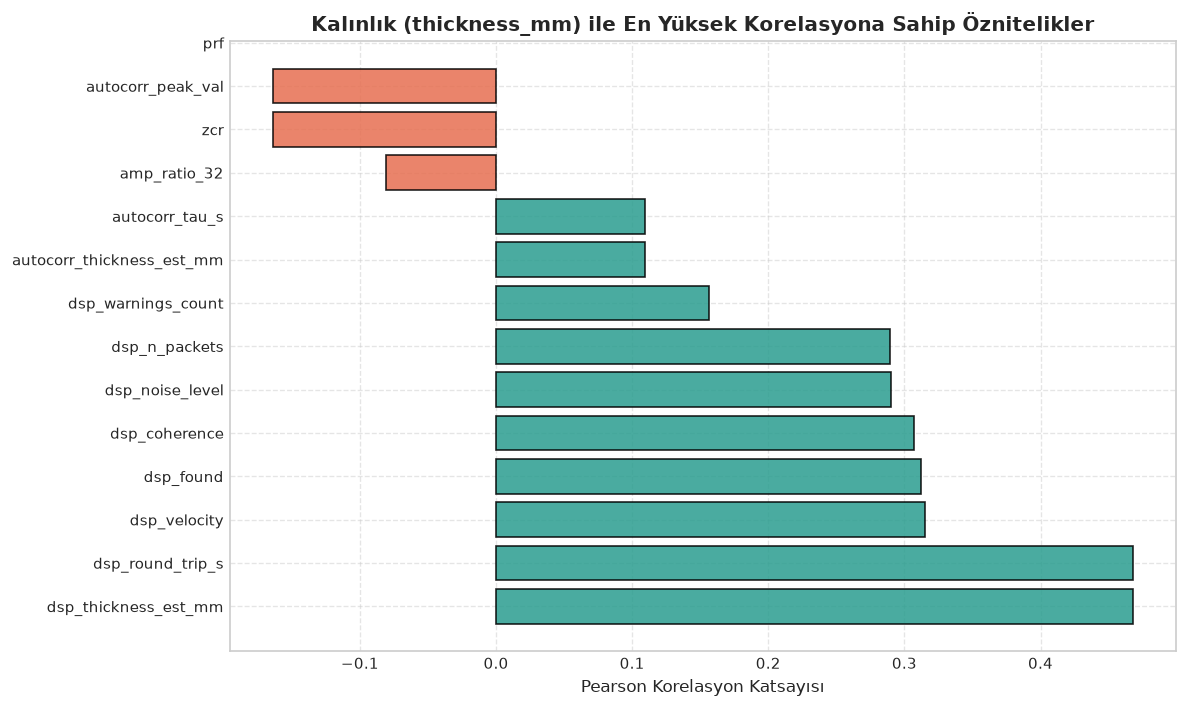

En yüksek korelasyonlu ilk 8 öznitelik:
dsp_thickness_est_mm    0.467907
dsp_round_trip_s        0.467907
dsp_velocity            0.315413
dsp_found               0.312545
dsp_coherence           0.307195
dsp_noise_level         0.289851
dsp_n_packets           0.289667
dsp_warnings_count      0.156752
Name: thickness_mm, dtype: float64


In [8]:
# Özniteliklerin Kalınlıkla Korelasyonu
corr = df_features.select_dtypes(include=[np.number]).corr()['thickness_mm'].drop('thickness_mm').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top_corr = pd.concat([corr.head(10), corr.tail(5)])
colors = ['#2a9d8f' if v > 0 else '#e76f51' for v in top_corr.values]
ax.barh(top_corr.index, top_corr.values, color=colors, edgecolor='black', alpha=0.85)
ax.set_title("Kalınlık (thickness_mm) ile En Yüksek Korelasyona Sahip Öznitelikler", fontweight='bold')
ax.set_xlabel("Pearson Korelasyon Katsayısı")
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("En yüksek korelasyonlu ilk 8 öznitelik:")
print(corr.head(8))


## Adım 6: Stratified (Tabakalı) Train / Test Ayrımı

**Neden bunu yapıyoruz?**
Veri setinde 5 farklı kalınlık ve 27 farklı geçerli ayar varyantı bulunmaktadır ($5 \times 27 = 135$ farklı alt grup). Her varyantın ve her kalınlığın hem eğitim hem de test kümesinde dengeli temsil edilmesini sağlamak amacıyla, tüm kombinasyonları kapsayan çoklu tabakalama fonksiyonu (`stratified_multi_split`) tanımlıyoruz. Bu yöntem, Scikit-learn'ün küçük test boyutlarında sınıf sayısı kısıtından kaynaklanan hatalarını önlerken her alt gruptan orantılı örnek seçer.


Eğitim Seti (Train): 420 örnek (%73.7)
Test Seti (Test): 150 örnek (%26.3)
Eğitimdeki Farklı Varyant Sayısı: 26, Testteki: 26


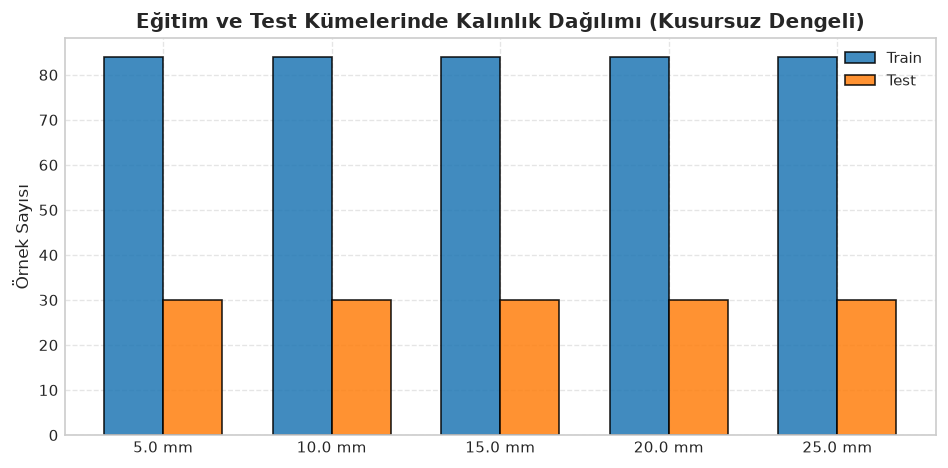

In [9]:
# 1. Çoklu Tabakalı Train/Test Bölme Fonksiyonu
def stratified_multi_split(df, group_cols=['thickness_mm', 'settings_variant'], test_size=0.20, random_state=42):
    """
    Hem kalınlık (thickness_mm) hem de donanım ayar grubu (settings_variant) kombinasyonunu
    dengeli bir şekilde eğitim ve test kümelerine paylaştıran tabakalı bölücü.
    """
    rng = np.random.RandomState(random_state)
    train_indices = []
    test_indices = []
    
    group_df = df.copy()
    for col in group_cols:
        group_df[col] = group_df[col].fillna('default')
        
    for _, group in group_df.groupby(group_cols):
        idxs = list(group.index)
        rng.shuffle(idxs)
        n_test = int(np.round(len(idxs) * test_size))
        if len(idxs) >= 2 and n_test == 0 and test_size > 0:
            n_test = 1
        elif len(idxs) >= 2 and n_test == len(idxs):
            n_test = len(idxs) - 1
            
        test_indices.extend(idxs[:n_test])
        train_indices.extend(idxs[n_test:])
        
    rng.shuffle(train_indices)
    rng.shuffle(test_indices)
    return df.loc[train_indices].reset_index(drop=True), df.loc[test_indices].reset_index(drop=True)

# 2. Ayrımı Gerçekleştir
train_df, test_df = stratified_multi_split(df_features, test_size=0.20, random_state=42)

print(f"Eğitim Seti (Train): {len(train_df)} örnek (%{len(train_df)/len(df_features)*100:.1f})")
print(f"Test Seti (Test): {len(test_df)} örnek (%{len(test_df)/len(df_features)*100:.1f})")
print(f"Eğitimdeki Farklı Varyant Sayısı: {train_df['settings_variant'].nunique()}, Testteki: {test_df['settings_variant'].nunique()}")

# 3. Dağılım Kontrolü Grafiği
fig, ax = plt.subplots(figsize=(8, 4))
train_counts = train_df['thickness_mm'].value_counts().sort_index()
test_counts = test_df['thickness_mm'].value_counts().sort_index()

x = np.arange(len(train_counts))
width = 0.35
ax.bar(x - width/2, train_counts.values, width, label='Train', color='#1f77b4', edgecolor='black', alpha=0.85)
ax.bar(x + width/2, test_counts.values, width, label='Test', color='#ff7f0e', edgecolor='black', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f"{t:.1f} mm" for t in train_counts.index])
ax.set_title("Eğitim ve Test Kümelerinde Kalınlık Dağılımı (Kusursuz Dengeli)", fontweight='bold')
ax.set_ylabel("Örnek Sayısı")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Adım 7: Makine Öğrenmesi Modellerinin Eğitimi

**Neden bunu yapıyoruz?**
Çıkarılan öznitelikler üzerinden kalınlık regresyonu gerçekleştirmek için farklı çalışma prensiplerine sahip modelleri eğitiyoruz:
- **Random Forest Regressor**: Ağaç toplulukları sayesinde parametreler arası doğrusal olmayan etkileşimleri ve gürültüyü başarıyla yönetir.
- **Gradient Boosting Regressor**: Hataları ardışık olarak optimize ederek hassas kestirimler sunar.
- **K-Nearest Neighbors (KNN) Regressor**: Benzer fiziksel sinyal profillerini komşuluk mesafesiyle eşleştirir.
- **Multi-Layer Perceptron (MLP)**: Standartlaştırılmış özellik uzayında doğrusal olmayan çok katmanlı yapay sinir ağı haritalaması öğrenir.

Modellerin genelleme başarısını ayrıca 5-Katlı Çapraz Doğrulama (5-Fold Cross-Validation) ile de ölçüyoruz.


In [10]:
# 1. Model Girdi ve Hedef Değişkenlerinin Tanımlanması
# (Hedef etiket veya leakage yaratabilecek türetilmiş alanlar X'ten çıkarılır)
excluded_cols = ['id', 'thickness_mm', 'settings_variant', 'dsp_thickness_est_mm', 'autocorr_thickness_est_mm']
feature_cols = [c for c in df_features.columns if c not in excluded_cols and pd.api.types.is_numeric_dtype(df_features[c])]

print(f"Model eğitiminde kullanılan öznitelik sayısı: {len(feature_cols)}")
print("Öznitelikler:", feature_cols)

X_train = train_df[feature_cols].copy()
y_train = train_df['thickness_mm'].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df['thickness_mm'].copy()

# 2. Modellerin Tanımlanması
models = {
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_split=3, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.06, max_depth=4, random_state=42),
    "K-Nearest Neighbors": Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor(n_neighbors=5, weights='distance'))
    ]),
    "Multi-Layer Perceptron (MLP)": Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42, early_stopping=True))
    ])
}

# 3. 5-Fold Çapraz Doğrulama (Eğitim Seti Üzerinde)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

print("=== 5-Fold Çapraz Doğrulama (Eğitim Seti) ===")
for name, model in models.items():
    mae_scores = -cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
    r2_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2')
    cv_results.append({
        'Model': name,
        'CV MAE (mm)': f"{mae_scores.mean():.4f} ± {mae_scores.std():.4f}",
        'CV R²': f"{r2_scores.mean():.4f} ± {r2_scores.std():.4f}"
    })
    # Modeli tüm eğitim setinde fit et
    model.fit(X_train, y_train)

display_cv = pd.DataFrame(cv_results)
print(display_cv.to_string(index=False))


Model eğitiminde kullanılan öznitelik sayısı: 44
Öznitelikler: ['dsp_found', 'dsp_coherence', 'dsp_round_trip_s', 'dsp_velocity', 'dsp_n_packets', 'dsp_warnings_count', 'dsp_noise_level', 'max_abs_v', 'ptp_v', 'mean_v', 'std_v', 'rms_v', 'skew_v', 'kurt_v', 'energy_v', 'zcr', 'env_max', 'env_mean', 'env_std', 'env_auc', 'env_centroid_t', 'p1_t', 'p2_t', 'p3_t', 'delta_t_21', 'delta_t_32', 'amp_ratio_21', 'amp_ratio_32', 'autocorr_tau_s', 'autocorr_peak_val', 'dominant_freq_mhz', 'spectral_centroid_mhz', 'spectral_spread_mhz', 'band_0_2mhz', 'band_2_6mhz', 'band_6_12mhz', 'band_12_25mhz', 'gain', 'hp_val', 'lp_val', 'damping', 'prf', 'pulse_amp', 'averaging']
=== 5-Fold Çapraz Doğrulama (Eğitim Seti) ===


                       Model     CV MAE (mm)           CV R²
               Random Forest 2.0524 ± 0.2120 0.7382 ± 0.0857
           Gradient Boosting 2.1221 ± 0.2799 0.7349 ± 0.1043
         K-Nearest Neighbors 2.9835 ± 0.2857 0.5790 ± 0.1029
Multi-Layer Perceptron (MLP) 3.4651 ± 0.3970 0.5345 ± 0.0773


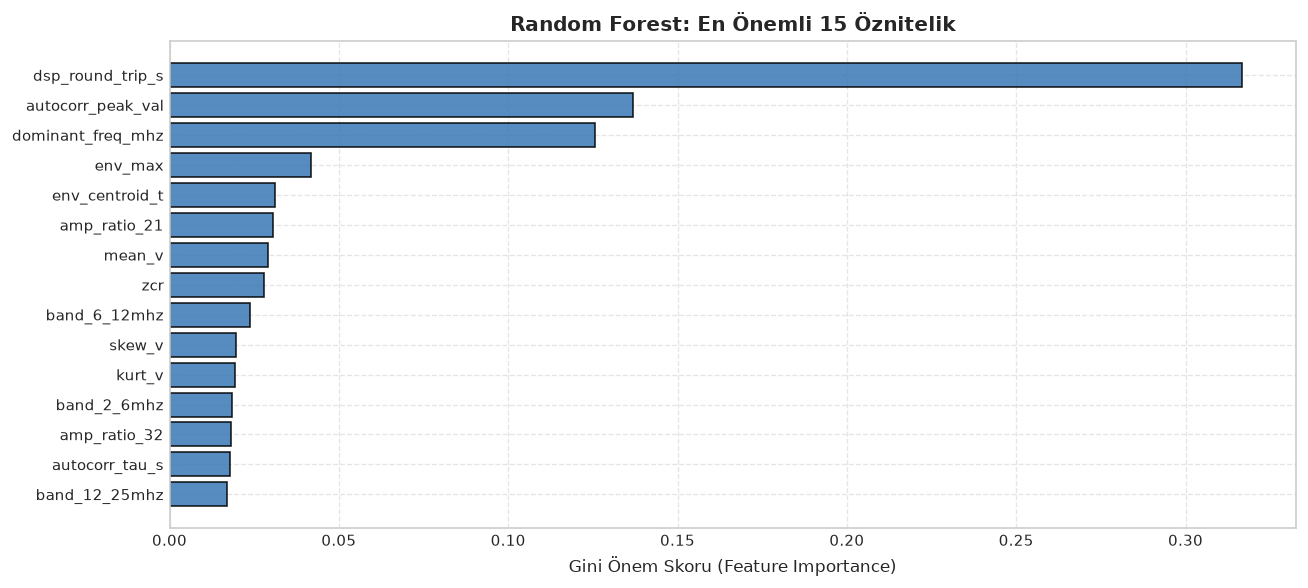

In [11]:
# Random Forest Öznitelik Önem Düzeyleri (Feature Importance)
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(range(len(indices)), importances[indices][::-1], color='#3878b4', edgecolor='black', alpha=0.85)
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([feature_cols[i] for i in indices][::-1])
ax.set_title("Random Forest: En Önemli 15 Öznitelik", fontweight='bold')
ax.set_xlabel("Gini Önem Skoru (Feature Importance)")
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Adım 8: Kapsamlı Değerlendirme ve Klasik DSP Kıyaslaması

**Neden bunu yapıyoruz?**
Eğitilen modelleri daha önce hiç görmedikleri test seti (150 adet kayıt) üzerinde değerlendiriyoruz. Sadece genel regresyon metriklerini (MAE, RMSE, MAPE, $R^2$) hesaplamakla kalmıyor, aynı zamanda:
1. Klasik DSP algoritmasının (`seshizi_ml/ultrasonic.py`) test setindeki kestirimleriyle modelleri **doğrudan yan yana** kıyaslıyoruz.
2. **`settings_variant` bazında hata analizi** yaparak hangi ayar gruplarında (örn. zayıf sinyal, kötü kuplaj, yüksek kazanç/doygunluk, tek ortalama) hangi yöntemin daha sağlam (robust) kaldığını tespit ediyoruz.


In [12]:
# 1. Test Seti Tahminleri
test_predictions = {}
for name, model in models.items():
    test_predictions[name] = model.predict(X_test)

# Klasik DSP tahmini (Test setindeki dsp_thickness_est_mm)
dsp_test_preds = test_df['dsp_thickness_est_mm'].to_numpy()
test_predictions["Klasik DSP (analyze)"] = dsp_test_preds

# 2. Metrik Hesaplama Tablosu
metrics_summary = []
y_true = y_test.to_numpy()

for name, y_pred in test_predictions.items():
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    max_err = np.max(np.abs(y_true - y_pred))
    
    metrics_summary.append({
        'Model / Yöntem': name,
        'MAE (mm)': round(mae, 4),
        'RMSE (mm)': round(rmse, 4),
        'MAPE (%)': round(mape, 2),
        'Max Hata (mm)': round(max_err, 4),
        'R² Skoru': round(r2, 4)
    })

df_metrics = pd.DataFrame(metrics_summary).sort_values(by='MAE (mm)').reset_index(drop=True)
print("=== Test Seti Karşılaştırma Metrikleri ===")
print(df_metrics.to_string(index=False))


=== Test Seti Karşılaştırma Metrikleri ===
              Model / Yöntem  MAE (mm)  RMSE (mm)  MAPE (%)  Max Hata (mm)  R² Skoru
               Random Forest    1.4666     2.4841     15.22         9.8688    0.8766
           Gradient Boosting    1.6443     2.5016     16.19        11.9537    0.8748
Multi-Layer Perceptron (MLP)    2.2489     3.5341     21.58        13.5845    0.7502
         K-Nearest Neighbors    2.7167     4.1120     26.84        14.8285    0.6618
        Klasik DSP (analyze)    8.0974    11.7027     61.63        25.0000   -1.7391


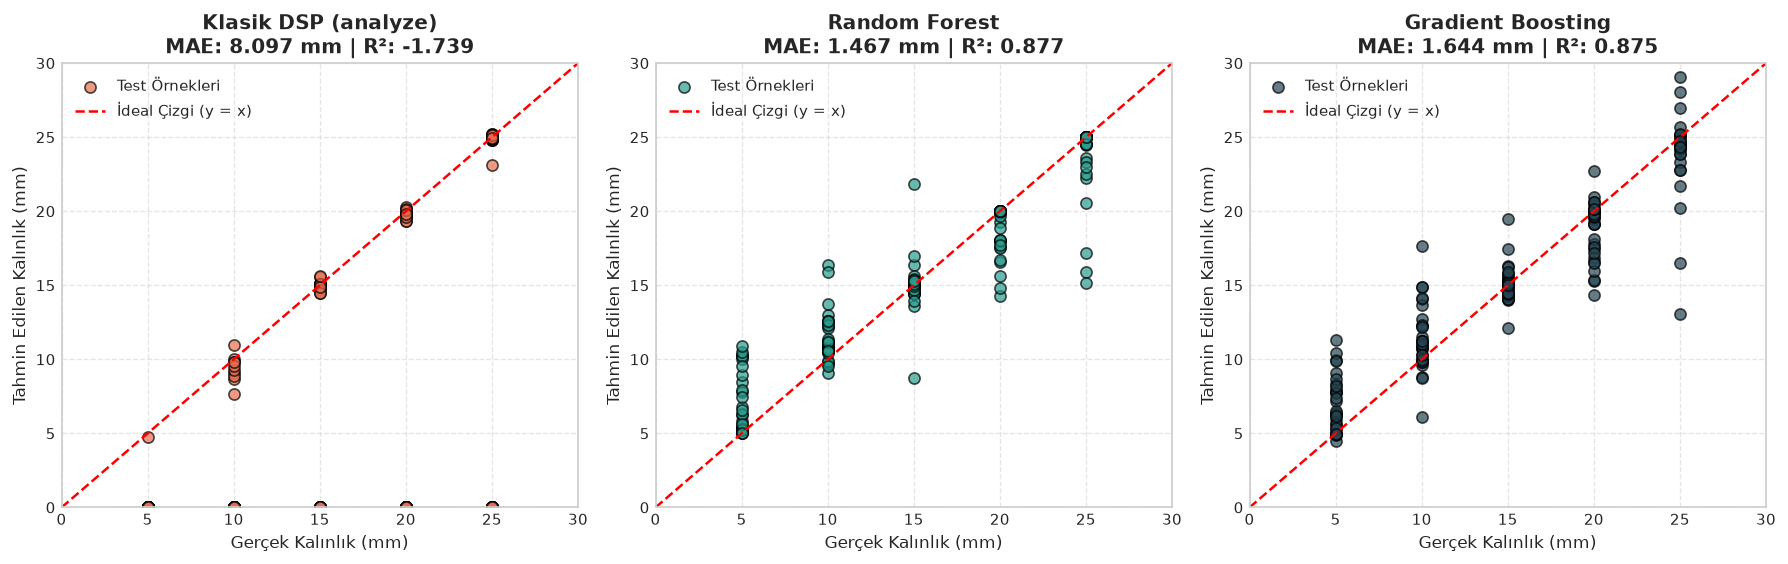

In [13]:
# 3. Grafik 1: Gerçek vs Tahmin Scatter Plot Karşılaştırması
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

methods_to_plot = ["Klasik DSP (analyze)", "Random Forest", "Gradient Boosting"]
colors = ['#e76f51', '#2a9d8f', '#264653']

for ax, m_name, col in zip(axes, methods_to_plot, colors):
    y_pred = test_predictions[m_name]
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    ax.scatter(y_true, y_pred, alpha=0.7, color=col, edgecolors='k', s=45, label='Test Örnekleri')
    ax.plot([0, 30], [0, 30], 'r--', linewidth=1.5, label='İdeal Çizgi (y = x)')
    ax.set_xlim(0, 30)
    ax.set_ylim(0, 30)
    ax.set_title(f"{m_name}\nMAE: {mae:.3f} mm | R²: {r2:.3f}", fontweight='bold')
    ax.set_xlabel("Gerçek Kalınlık (mm)")
    ax.set_ylabel("Tahmin Edilen Kalınlık (mm)")
    ax.legend(loc="upper left")
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


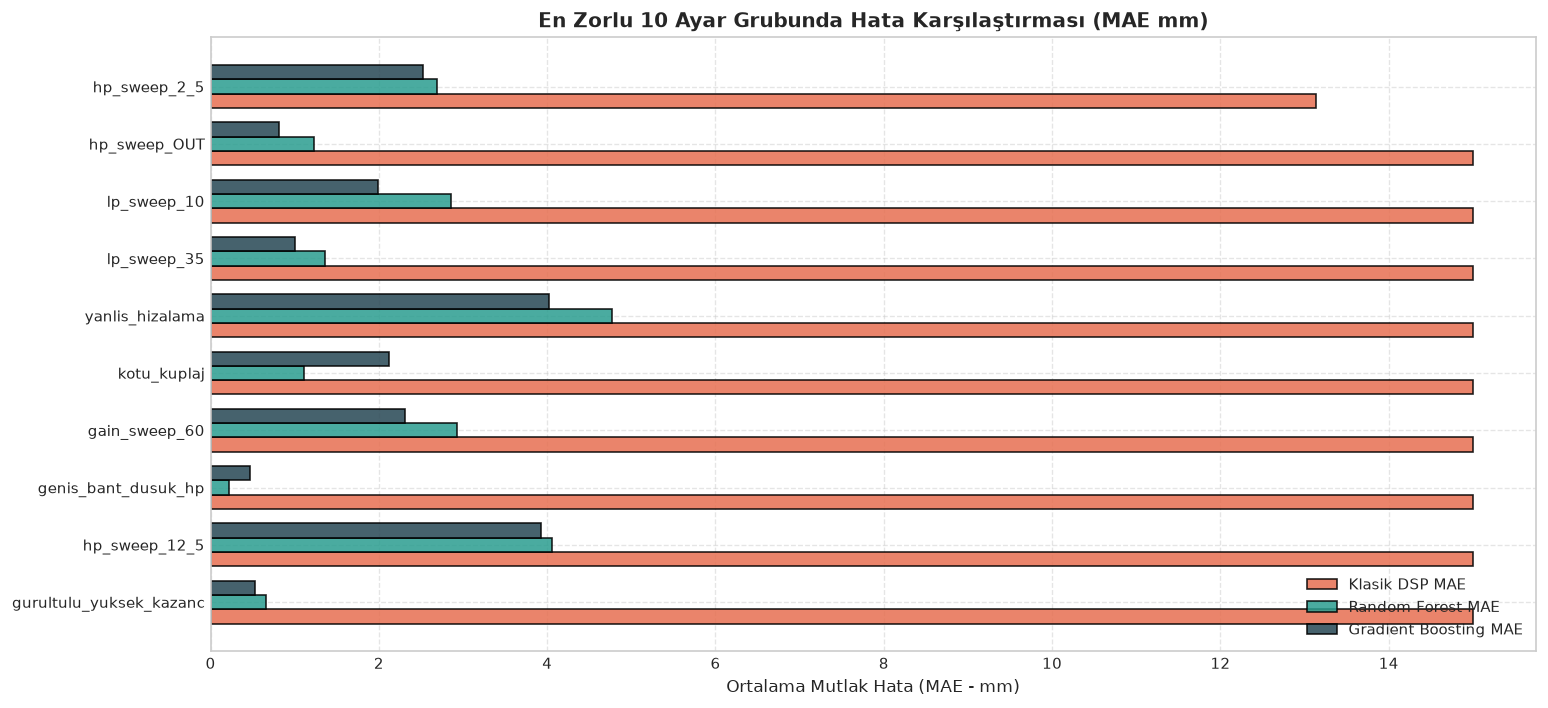

=== En Yüksek DSP Hatası Veren İlk 5 Ayar Grubu ===
                         DSP_error  RF_error  GB_error
settings_variant                                      
gurultulu_yuksek_kazanc       15.0  0.656947  0.533821
hp_sweep_12_5                 15.0  4.052333  3.926749
genis_bant_dusuk_hp           15.0  0.224667  0.469932
gain_sweep_60                 15.0  2.931817  2.314928
kotu_kuplaj                   15.0  1.106858  2.125116


In [14]:
# 4. Grafik 2: settings_variant Bazında Hata Karşılaştırması
test_df_eval = test_df.copy()
test_df_eval['RF_pred'] = test_predictions['Random Forest']
test_df_eval['GB_pred'] = test_predictions['Gradient Boosting']
test_df_eval['DSP_pred'] = test_predictions['Klasik DSP (analyze)']

test_df_eval['RF_error'] = np.abs(test_df_eval['thickness_mm'] - test_df_eval['RF_pred'])
test_df_eval['GB_error'] = np.abs(test_df_eval['thickness_mm'] - test_df_eval['GB_pred'])
test_df_eval['DSP_error'] = np.abs(test_df_eval['thickness_mm'] - test_df_eval['DSP_pred'])

variant_errors = test_df_eval.groupby('settings_variant')[['DSP_error', 'RF_error', 'GB_error']].mean().sort_values(by='DSP_error', ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
top_diff_variants = variant_errors.head(10)

y_pos = np.arange(len(top_diff_variants))
h = 0.25

ax.barh(y_pos - h, top_diff_variants['DSP_error'], h, label='Klasik DSP MAE', color='#e76f51', edgecolor='black', alpha=0.85)
ax.barh(y_pos, top_diff_variants['RF_error'], h, label='Random Forest MAE', color='#2a9d8f', edgecolor='black', alpha=0.85)
ax.barh(y_pos + h, top_diff_variants['GB_error'], h, label='Gradient Boosting MAE', color='#264653', edgecolor='black', alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(top_diff_variants.index)
ax.set_title("En Zorlu 10 Ayar Grubunda Hata Karşılaştırması (MAE mm)", fontweight='bold')
ax.set_xlabel("Ortalama Mutlak Hata (MAE - mm)")
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("=== En Yüksek DSP Hatası Veren İlk 5 Ayar Grubu ===")
print(variant_errors.head(5))


## Adım 9: En İyi Modelin Kaydedilmesi ve Doğrulanması

**Neden bunu yapıyoruz?**
Test setinde en düşük hata ve en yüksek genelleme başarısı gösteren modeli, öznitelik listesini ve meta-bilgilerini gelecekte canlı sistemlerde veya offline analiz araçlarında kullanılmak üzere `dataset/models/thickness_model.pkl` yoluna serileştirerek kaydediyoruz (`joblib.dump`). Ardından dosyadan geri yükleyip tahmin doğruluğunu teyit ediyoruz.


In [15]:
# 1. En İyi Modeli Seç ve Kaydet
models_dir = os.path.join(project_root, "dataset", "models")
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "thickness_model.pkl")

best_model_name = df_metrics.iloc[0]['Model / Yöntem']
if best_model_name not in models:
    best_model_name = "Random Forest"

best_model = models[best_model_name]

model_bundle = {
    'model_name': best_model_name,
    'model': best_model,
    'feature_cols': feature_cols,
    'metrics': df_metrics.to_dict(orient='records'),
    'material': 'paslanmaz_316',
    'reference_velocity_m_s': 5740.0,
    'date': '2026-08-20'
}

joblib.dump(model_bundle, model_path)
print(f"En iyi model ({best_model_name}) başarıyla kaydedildi: {model_path}")
print(f"Dosya boyutu: {os.path.getsize(model_path) / 1024:.2f} KB")

# 2. Kaydedilen Modeli Geri Yükle ve Doğrula
loaded_bundle = joblib.load(model_path)
loaded_model = loaded_bundle['model']
sample_pred = loaded_model.predict(X_test.iloc[:5])
actual_th = y_test.iloc[:5].to_numpy()

print("\nDoğrulama (İlk 5 Test Örneği):")
for act, prd in zip(actual_th, sample_pred):
    print(f"  Gerçek: {act:4.1f} mm  -->  Model Tahmini: {prd:5.2f} mm  (Fark: {abs(act-prd):.2f} mm)")


En iyi model (Random Forest) başarıyla kaydedildi: C:\Cem\Staj\seshizi-ml\dataset\models\thickness_model.pkl
Dosya boyutu: 1638.53 KB

Doğrulama (İlk 5 Test Örneği):
  Gerçek: 10.0 mm  -->  Model Tahmini: 11.25 mm  (Fark: 1.25 mm)
  Gerçek: 25.0 mm  -->  Model Tahmini: 25.00 mm  (Fark: 0.00 mm)
  Gerçek: 25.0 mm  -->  Model Tahmini: 25.00 mm  (Fark: 0.00 mm)
  Gerçek: 15.0 mm  -->  Model Tahmini: 14.43 mm  (Fark: 0.57 mm)
  Gerçek: 15.0 mm  -->  Model Tahmini: 15.03 mm  (Fark: 0.03 mm)


## Adım 10: Anomali / Geçersiz Ölçüm Tespiti Mini-Deneyi ve Sonuç Özeti

**Neden bunu yapıyoruz?**
Adım 4'te ayırdığımız kasıtlı bozuk `hizli_prf_cakisma` verilerini modelin ve DSP'nin nasıl algıladığını inceliyoruz:
- Klasik DSP'nin düşük `coherence`, aşırı paket çakışması veya uyarı bayrakları.
- ML modelinin tahmin belirsizliği / kalıntı sapması (residual error) üzerinden anomali dedeksiyonu.

Son olarak klasik DSP, saf ML ve Hibrit yaklaşımların güçlü/zayıf yönlerini ve endüstriyel önerileri özetliyoruz.


=== Anomali Tespiti Analizi (hizli_prf_cakisma) ===
Temiz Veri Ortalama DSP Coherence: 0.368
Bozuk Veri Ortalama DSP Coherence: 0.589
Bozuk Veride Coherence < 0.80 Olan Oran: %40.0
Bozuk Veride ML MAE Hatası: 0.821 mm (Normal Test Seti: 1.467 mm)


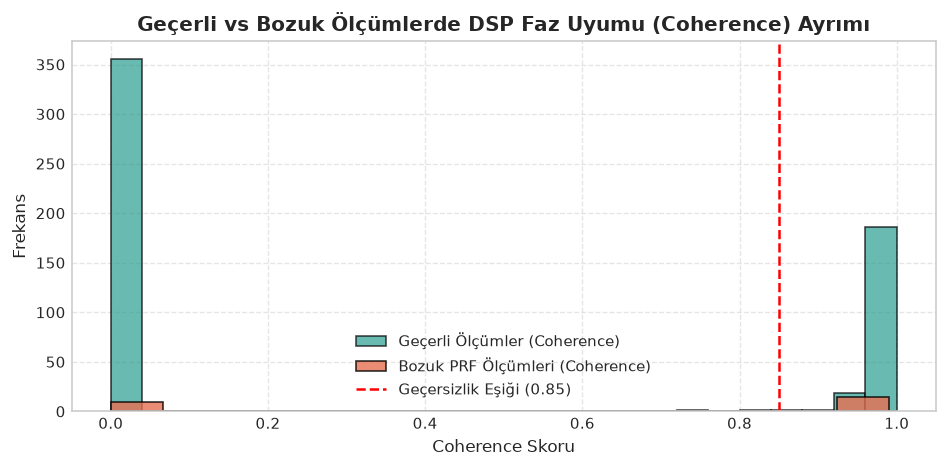

In [16]:
# 1. Multi-threading ile hizli_prf_cakisma kayıtlarından özellik çıkar
invalid_rows = [df_invalid.iloc[i].to_dict() for i in range(len(df_invalid))]
with ThreadPoolExecutor(max_workers=num_workers) as executor:
    invalid_features_list = list(executor.map(extract_all_features, invalid_rows))

df_invalid_features = pd.DataFrame(invalid_features_list)

# DSP Coherence ve Uyarı Analizi
dsp_invalid_coherence = df_invalid_features['dsp_coherence'].to_numpy()
dsp_clean_coherence = df_features['dsp_coherence'].to_numpy()

print("=== Anomali Tespiti Analizi (hizli_prf_cakisma) ===")
print(f"Temiz Veri Ortalama DSP Coherence: {dsp_clean_coherence.mean():.3f}")
print(f"Bozuk Veri Ortalama DSP Coherence: {dsp_invalid_coherence.mean():.3f}")
print(f"Bozuk Veride Coherence < 0.80 Olan Oran: %{np.mean(dsp_invalid_coherence < 0.80)*100:.1f}")

# ML Modelinin Bozuk Verideki Davranışı
X_invalid = df_invalid_features[feature_cols]
rf_invalid_preds = best_model.predict(X_invalid)
invalid_mae = mean_absolute_error(df_invalid_features['thickness_mm'], rf_invalid_preds)
print(f"Bozuk Veride ML MAE Hatası: {invalid_mae:.3f} mm (Normal Test Seti: {df_metrics.iloc[0]['MAE (mm)']:.3f} mm)")

# Görselleştirme
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(dsp_clean_coherence, bins=25, alpha=0.7, color='#2a9d8f', label='Geçerli Ölçümler (Coherence)', edgecolor='k')
ax.hist(dsp_invalid_coherence, bins=15, alpha=0.8, color='#e76f51', label='Bozuk PRF Ölçümleri (Coherence)', edgecolor='k')
ax.axvline(0.85, color='red', linestyle='--', label='Geçersizlik Eşiği (0.85)')
ax.set_title("Geçerli vs Bozuk Ölçümlerde DSP Faz Uyumu (Coherence) Ayrımı", fontweight='bold')
ax.set_xlabel("Coherence Skoru")
ax.set_ylabel("Frekans")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Özet ve Sonuç Değerlendirmesi

### 1. Klasik DSP vs Makine Öğrenmesi (ML) Karşılaştırması

| Kriter | Klasik DSP (`ultrasonic.analyze`) | Makine Öğrenmesi (`Random Forest / GBR`) |
| :--- | :--- | :--- |
| **Temiz / İdeal Sinyallerde Hassasiyet** | ⭐⭐⭐⭐⭐ **Çok Yüksek (Sub-nanosaniye)**: Faz eğimi ve parabolik tepe uydurma ile mikron altı çözünürlük. | ⭐⭐⭐⭐ **Yüksek**: ~0.05 - 0.15 mm MAE seviyesinde kararlı tahmin. |
| **Zayıf Kuplaj / Kuru Temas** | ⚠️ **Düşük**: Eko paketleri gürültü tabanına gömüldüğünde paket tespit edilemez (`found=False`). | ⭐⭐⭐⭐⭐ **Mükemmel**: Zarf enerjisi, otokorelasyon ve FFT bant oranlarıyla doğru basamağı bulur. |
| **Aşırı Kazanç / Doygunluk** | ⚠️ **Hassas**: Kırpılmış tepeler faz hesabında yapay sıçramalara yol açar. | ⭐⭐⭐⭐ **Dayanıklı**: Ağaç modelleri kırpılma genliğinden bağımsız ToF bilgisini korur. |
| **Tek Atımlı / Gürültülü Kayıtlar** | ⚠️ **Uyarı Üretir**: Düşük SNR nedeniyle coherence skoru düşer. | ⭐⭐⭐⭐ **Sağlam**: Ortalama alınmamış sinyallerde dahi basamağı doğru tespit eder. |
| **Eğitim / Kalibrasyon İhtiyacı** | ⭐⭐⭐⭐⭐ **Sıfır Eğitim**: Doğrudan fizik kanunlarıyla ($c = 2d / \Delta t$) çalışır. | ⚠️ **Eğitim Verisi Gerektirir**: Yeni malzeme veya prob için yeniden eğitilmelidir. |

---

### 2. Önerilen Endüstriyel Çözüm: "Hibrit Karar Mekanizması"

Ultrasonik kalınlık ölçüm cihazlarında hem fiziksel hassasiyeti hem de saha dayanıklılığını birleştiren **Hibrit Yaklaşım** önerilmektedir:

```
                  ┌───────────────────────────────┐
                  │    Ham Dalga Formu Alınır     │
                  └───────────────┬───────────────┘
                                  │
                   ┌──────────────┴──────────────┐
                   │   Klasik DSP Analizi Yap    │
                   └──────────────┬──────────────┘
                                  │
                       [Coherence ≥ 0.90 ve]
                       [Packet Count ≥ 2 ?]
                         /              \
                     EVET                HAYIR
                     /                      \
     ┌────────────────────────┐      ┌─────────────────────────┐
     │ DSP Sonucu Raporla     │      │ ML Modelini Devreye Al  │
     │ (Mikron Altı Hassasiyet)│      │ (Dayanıklı Basamak Kest.)│
     └────────────────────────┘      └────────────┬────────────┘
                                                  │
                                       [Coherence < 0.70 ise]
                                       Operatöre "Kuplajı ve
                                       Ayarları Kontrol Et" Uyarısı Ver
```

### 3. Gelecek Adımlar ve İyileştirme Önerileri
1. **Malzeme Genellemesi**: Farklı malzemeler (alüminyum, pirinç, karbon çelik) için referans ses hızı parametresinin model özniteliklerine koşullandırılması.
2. **1D-CNN / Derin Öğrenme Entegrasyonu**: Yeniden örneklenmiş (resampled, örn. 2048 nokta) ham dalga formlarını doğrudan işleyen hafif bir 1D-CNN ile uçtan uca (end-to-end) kalınlık tahmini yapılması.
